In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset_ProjetML_2026.csv")

In [3]:
duplicated= df[df.duplicated()]
len(duplicated)

776

In [4]:
df.shape

(10500, 9)

In [5]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='str')

In [6]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [7]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


In [8]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie               str
Source                  str
Rapport_Collecte        str
dtype: object

In [9]:
for col in df.columns:
    print(col,'\t',df[col].dtype,'\t',df[col].isna().sum() )

Poids 	 float64 	 1029
Volume 	 float64 	 540
Conductivite 	 float64 	 1017
Opacite 	 float64 	 1035
Rigidite 	 float64 	 558
Prix_Revente 	 float64 	 536
Categorie 	 str 	 514
Source 	 str 	 536
Rapport_Collecte 	 str 	 0


In [10]:
df.isnull().sum()

Poids               1029
Volume               540
Conductivite        1017
Opacite             1035
Rigidite             558
Prix_Revente         536
Categorie            514
Source               536
Rapport_Collecte       0
dtype: int64

In [11]:
df.isnull()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,False,False,False,False,False,False,False,True,False
1,False,False,False,True,False,False,False,False,False
2,True,False,False,True,False,False,False,False,False
3,True,False,False,True,False,False,False,False,False
4,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...
10495,False,False,False,False,False,False,False,False,False
10496,False,False,False,False,False,False,False,True,False
10497,False,False,False,False,False,False,False,True,False
10498,False,False,False,False,False,False,False,False,False


In [12]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])


nombre de lignes: 10500
nombre de colonnes: 9


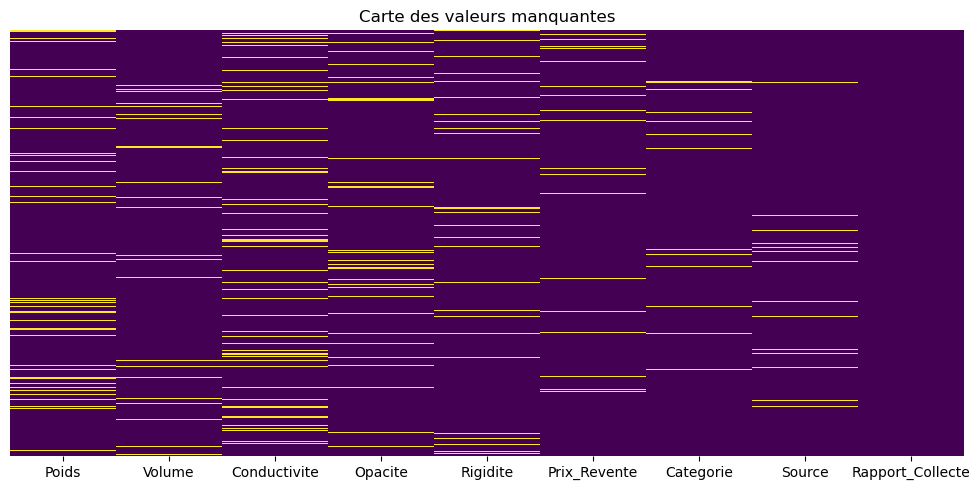

In [13]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Carte des valeurs manquantes")
plt.tight_layout()
plt.savefig("missing_values.png")
plt.show()

In [14]:
df["Poids_manquant"] = df["Poids"].isnull().astype(int)

In [15]:
print("=== Poids manquant selon Source ===")
print(df.groupby("Source")["Poids_manquant"].mean())

=== Poids manquant selon Source ===
Source
Centre_Tri            0.093139
Collecte_Citoyenne    0.100983
Usine_A               0.101132
Usine_B               0.098980
Name: Poids_manquant, dtype: float64


In [16]:
print("\n=== Poids manquant selon Categorie ===")
print(df.groupby("Categorie")["Poids_manquant"].mean())


=== Poids manquant selon Categorie ===
Categorie
Métal        0.111500
Papier       0.087144
Plastique    0.105903
Verre        0.086620
Name: Poids_manquant, dtype: float64


In [17]:
print("\n=== Corrélation entre les manquants ===")
missing_matrix = df[["Poids", "Volume", "Conductivite", 
                      "Opacite", "Rigidite", "Prix_Revente"]].isnull().astype(int)
print(missing_matrix.corr().round(2))


=== Corrélation entre les manquants ===
              Poids  Volume  Conductivite  Opacite  Rigidite  Prix_Revente
Poids          1.00   -0.01          0.01     0.01      0.01         -0.00
Volume        -0.01    1.00         -0.02     0.01      0.02         -0.01
Conductivite   0.01   -0.02          1.00     0.01     -0.00          0.01
Opacite        0.01    0.01          0.01     1.00     -0.00         -0.02
Rigidite       0.01    0.02         -0.00    -0.00      1.00         -0.01
Prix_Revente  -0.00   -0.01          0.01    -0.02     -0.01          1.00


In [18]:
df.drop(columns=["Poids_manquant"], inplace=True)

In [19]:
cols_numeriques = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite", "Prix_Revente"]

In [20]:
df_median = df.copy()
df_knn    = df.copy()
df_iter   = df.copy()

In [21]:
for col in cols_numeriques:
    median_val = df_median[col].median()
    df_median[col] = df_median[col].fillna(median_val)

print("✅ Imputation Médiane terminée")
print(df_median[cols_numeriques].isnull().sum())

✅ Imputation Médiane terminée
Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
Prix_Revente    0
dtype: int64


In [22]:
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[cols_numeriques] = knn_imputer.fit_transform(df_knn[cols_numeriques])

print("\n✅ Imputation KNN terminée")
print(df_knn[cols_numeriques].isnull().sum())



✅ Imputation KNN terminée
Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
Prix_Revente    0
dtype: int64


In [23]:
iter_imputer = IterativeImputer(random_state=42, max_iter=10)
df_iter[cols_numeriques] = iter_imputer.fit_transform(df_iter[cols_numeriques])

print("\n✅ Imputation Iterative terminée")
print(df_iter[cols_numeriques].isnull().sum())


✅ Imputation Iterative terminée
Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
Prix_Revente    0
dtype: int64


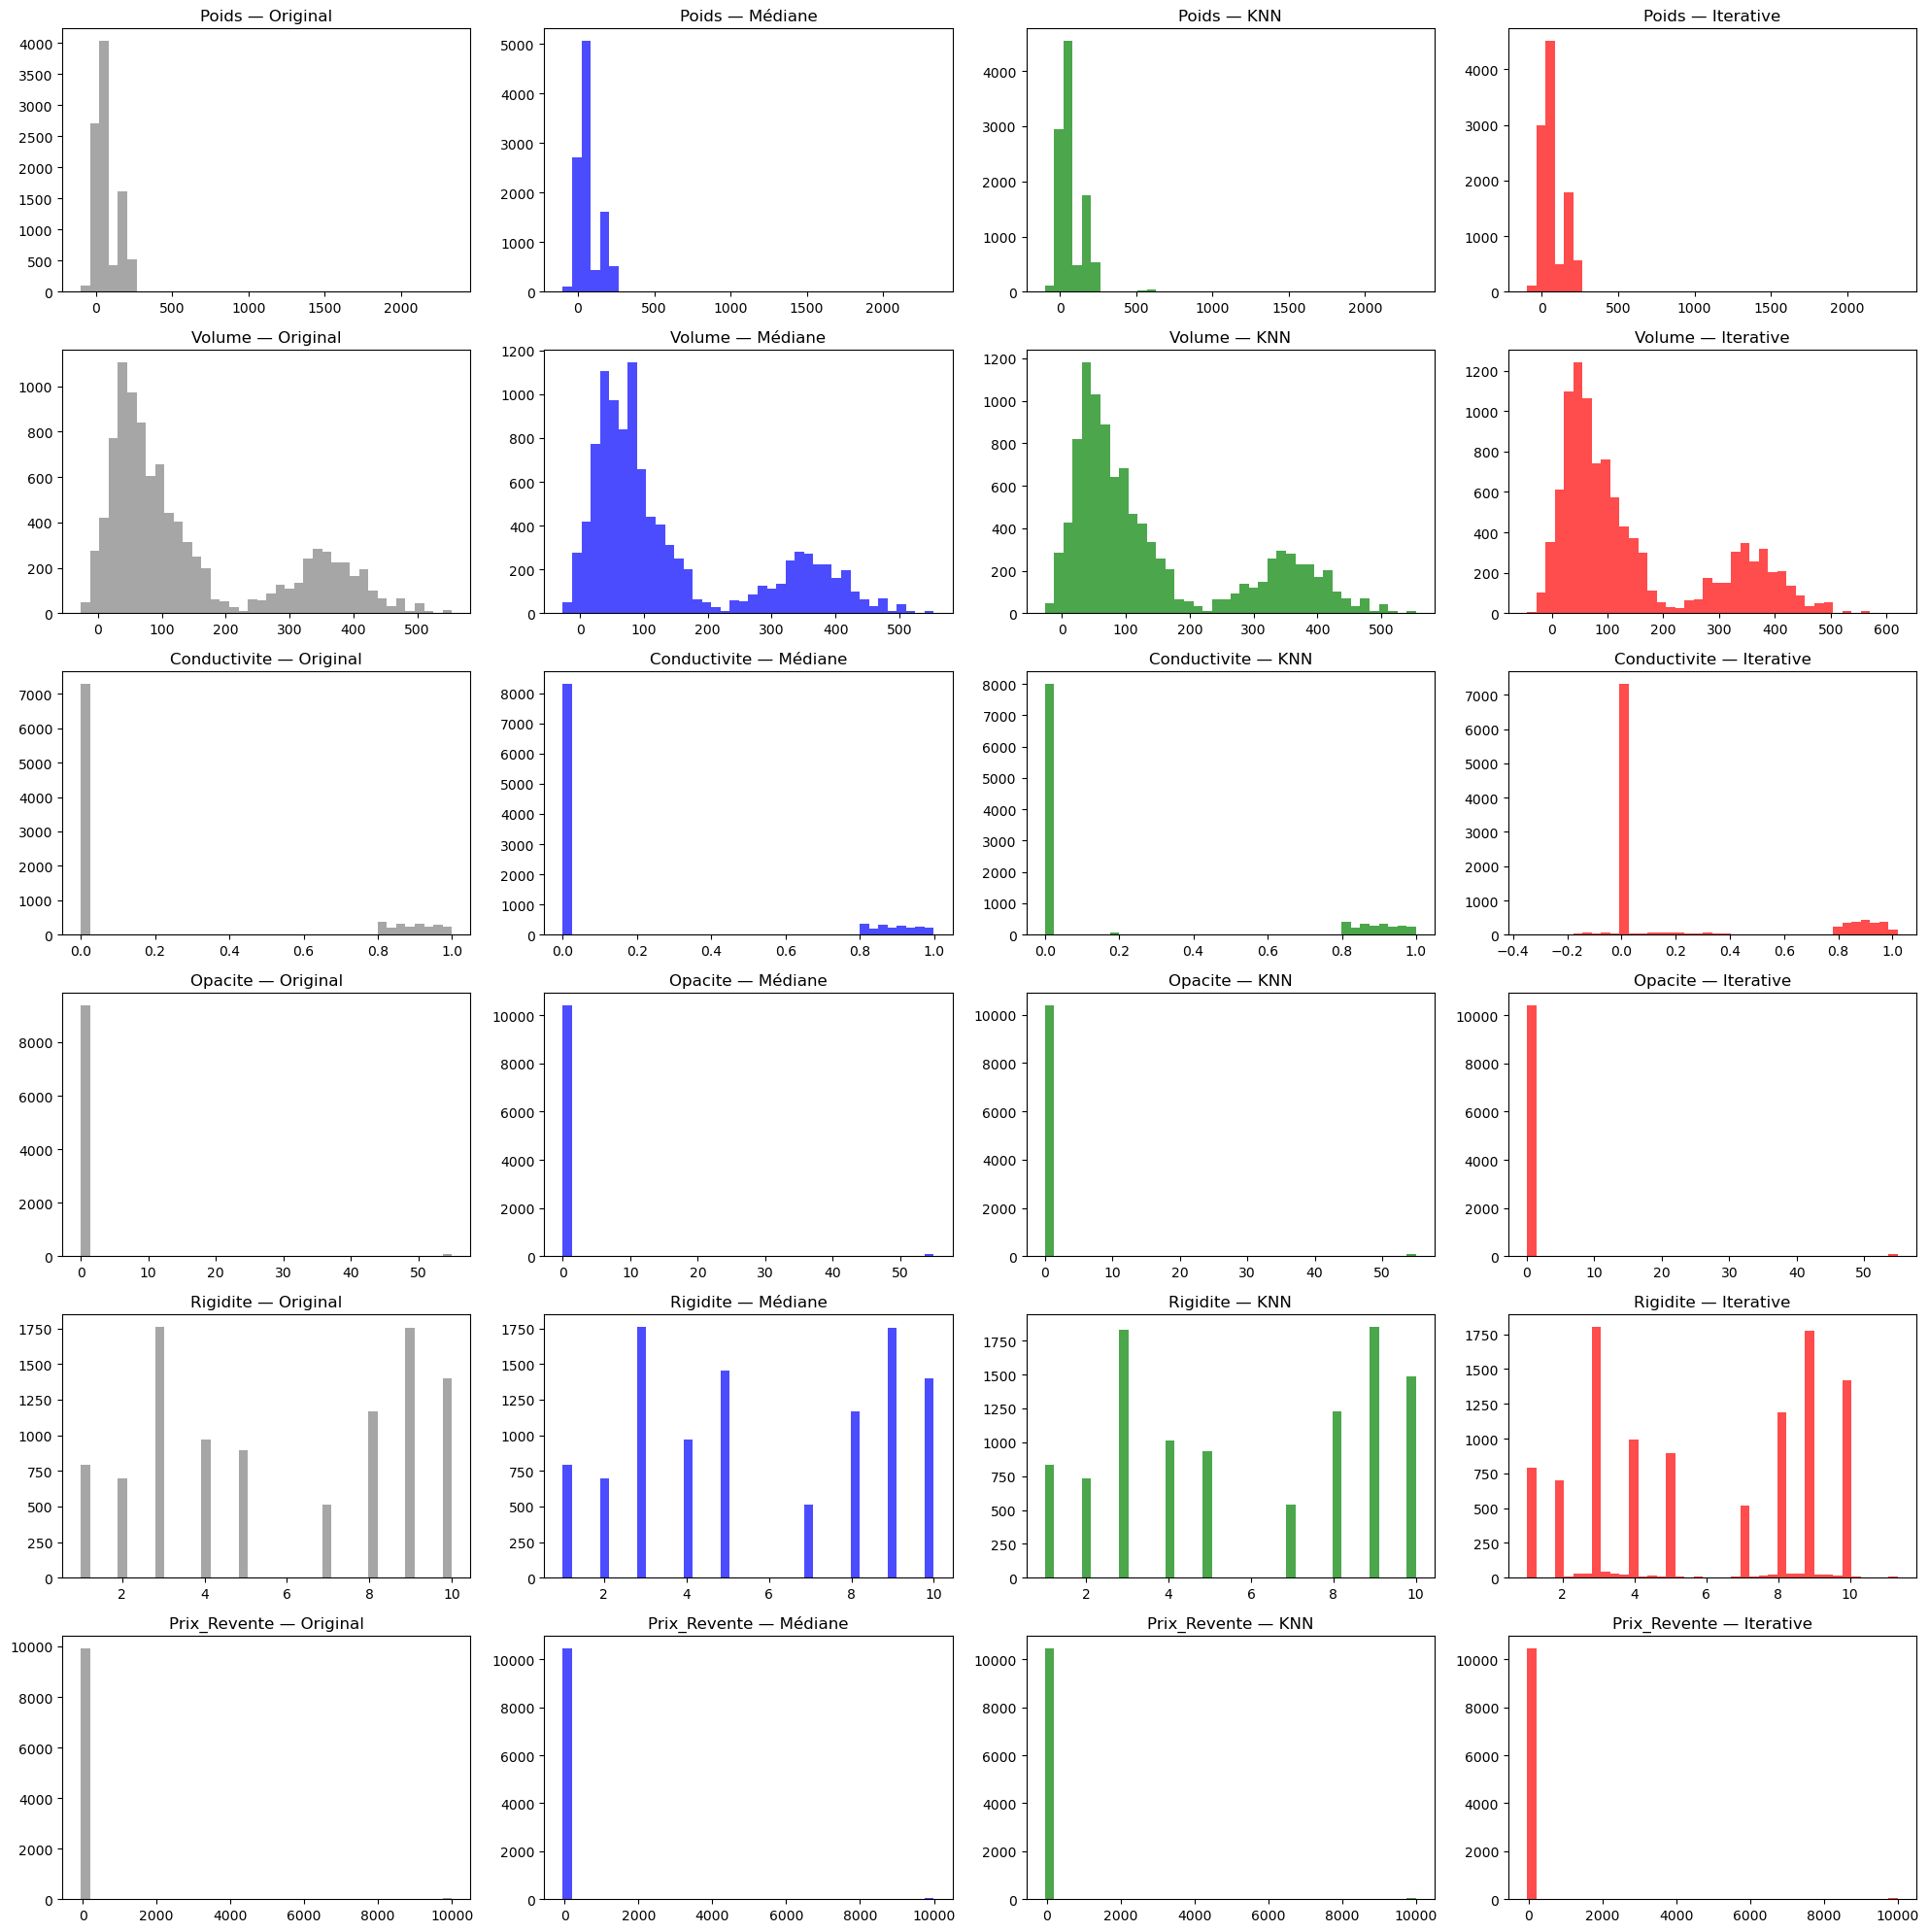

=== MOYENNE par méthode ===
Colonne           Original    Médiane        KNN  Iterative
-------------------------------------------------------
Poids               77.797     74.013     79.482     77.092
Volume             144.408    141.511    144.214    144.389
Conductivite         0.208      0.188      0.207      0.206
Opacite              1.160      1.101      1.179      1.161
Rigidite             5.887      5.840      5.892      5.890
Prix_Revente        58.588     55.808     56.110     58.419


In [24]:

# Colonnes à visualiser
cols_numeriques = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite", "Prix_Revente"]

fig, axes = plt.subplots(len(cols_numeriques), 4, figsize=(20, 20))

for i, col in enumerate(cols_numeriques):
    
    # Original (avec NaN ignorés)
    axes[i, 0].hist(df[col].dropna(), bins=40, color="gray", alpha=0.7)
    axes[i, 0].set_title(f"{col} — Original")
    
    # Médiane
    axes[i, 1].hist(df_median[col], bins=40, color="blue", alpha=0.7)
    axes[i, 1].set_title(f"{col} — Médiane")
    
    # KNN
    axes[i, 2].hist(df_knn[col], bins=40, color="green", alpha=0.7)
    axes[i, 2].set_title(f"{col} — KNN")
    
    # Iterative
    axes[i, 3].hist(df_iter[col], bins=40, color="red", alpha=0.7)
    axes[i, 3].set_title(f"{col} — Iterative")

plt.tight_layout()
plt.savefig("comparaison_imputation.png")
plt.show()

# ── Comparer les statistiques ──────────────────────────────
print("=== MOYENNE par méthode ===")
print(f"{'Colonne':<15} {'Original':>10} {'Médiane':>10} {'KNN':>10} {'Iterative':>10}")
print("-" * 55)
for col in cols_numeriques:
    orig = df[col].mean()
    med  = df_median[col].mean()
    knn  = df_knn[col].mean()
    it   = df_iter[col].mean()
    print(f"{col:<15} {orig:>10.3f} {med:>10.3f} {knn:>10.3f} {it:>10.3f}")

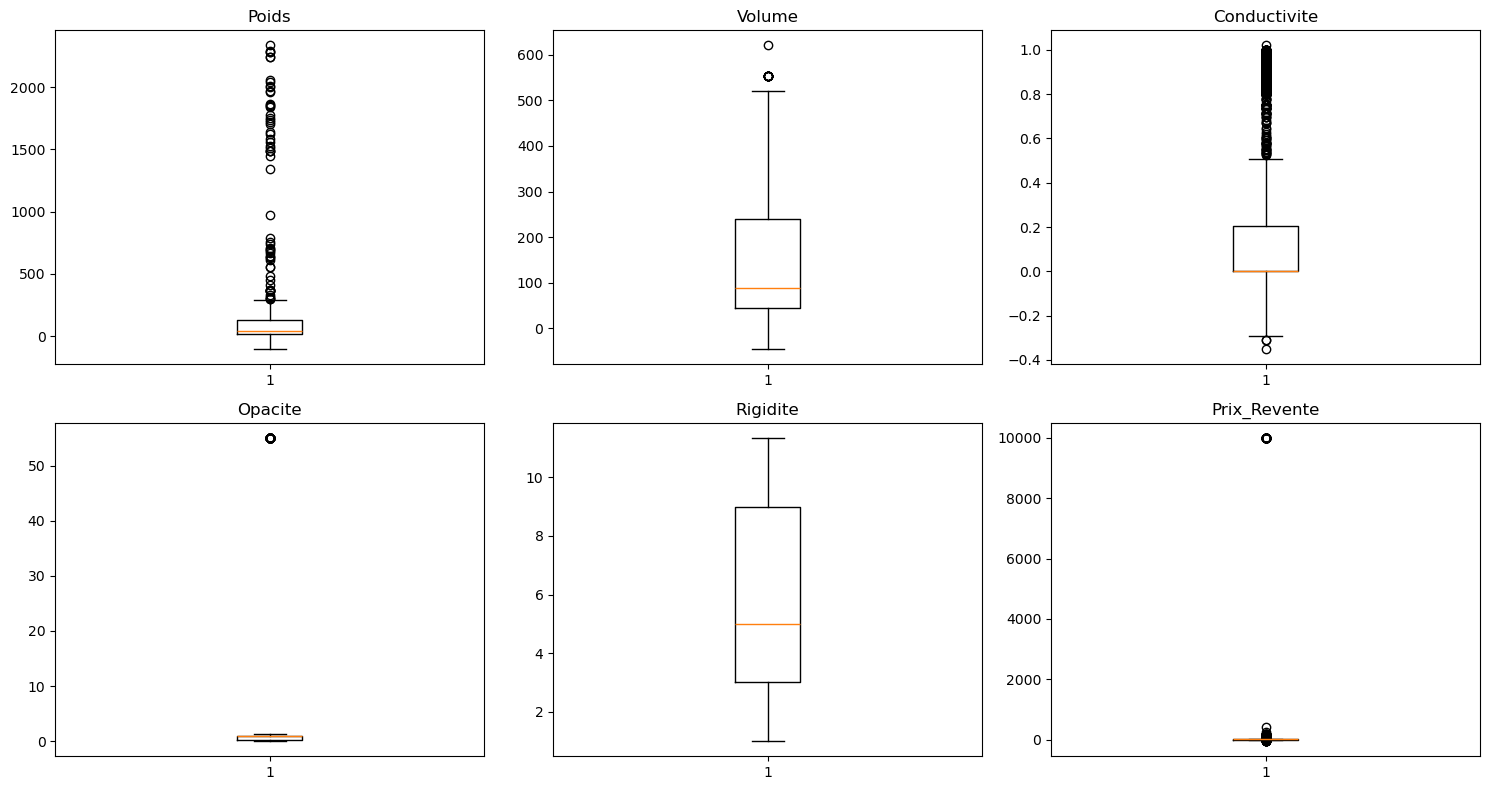

=== OUTLIERS détectés (méthode IQR) ===
Poids           → 61 outliers | borne: [-143.09, 291.35]
Volume          → 13 outliers | borne: [-248.14, 533.21]
Conductivite    → 2313 outliers | borne: [-0.31, 0.52]
Opacite         → 97 outliers | borne: [-0.91, 2.15]
Rigidite        → 0 outliers | borne: [-6.00, 18.00]
Prix_Revente    → 573 outliers | borne: [-12.42, 25.26]


In [25]:
# On travaille sur df_iter désormais
df_clean = df_iter.copy()

# ── Visualisation Boxplots ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numeriques):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("boxplots_outliers.png")
plt.show()

# ── Détecter les outliers avec la méthode IQR ──────────────
print("=== OUTLIERS détectés (méthode IQR) ===")
for col in cols_numeriques:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < borne_inf) | (df_clean[col] > borne_sup)]
    print(f"{col:<15} → {len(outliers)} outliers | borne: [{borne_inf:.2f}, {borne_sup:.2f}]")

=== OUTLIERS APRÈS CAPPING ===
Poids           → 0 outliers restants
Volume          → 0 outliers restants
Conductivite    → 0 outliers restants
Opacite         → 0 outliers restants
Rigidite        → 0 outliers restants
Prix_Revente    → 0 outliers restants


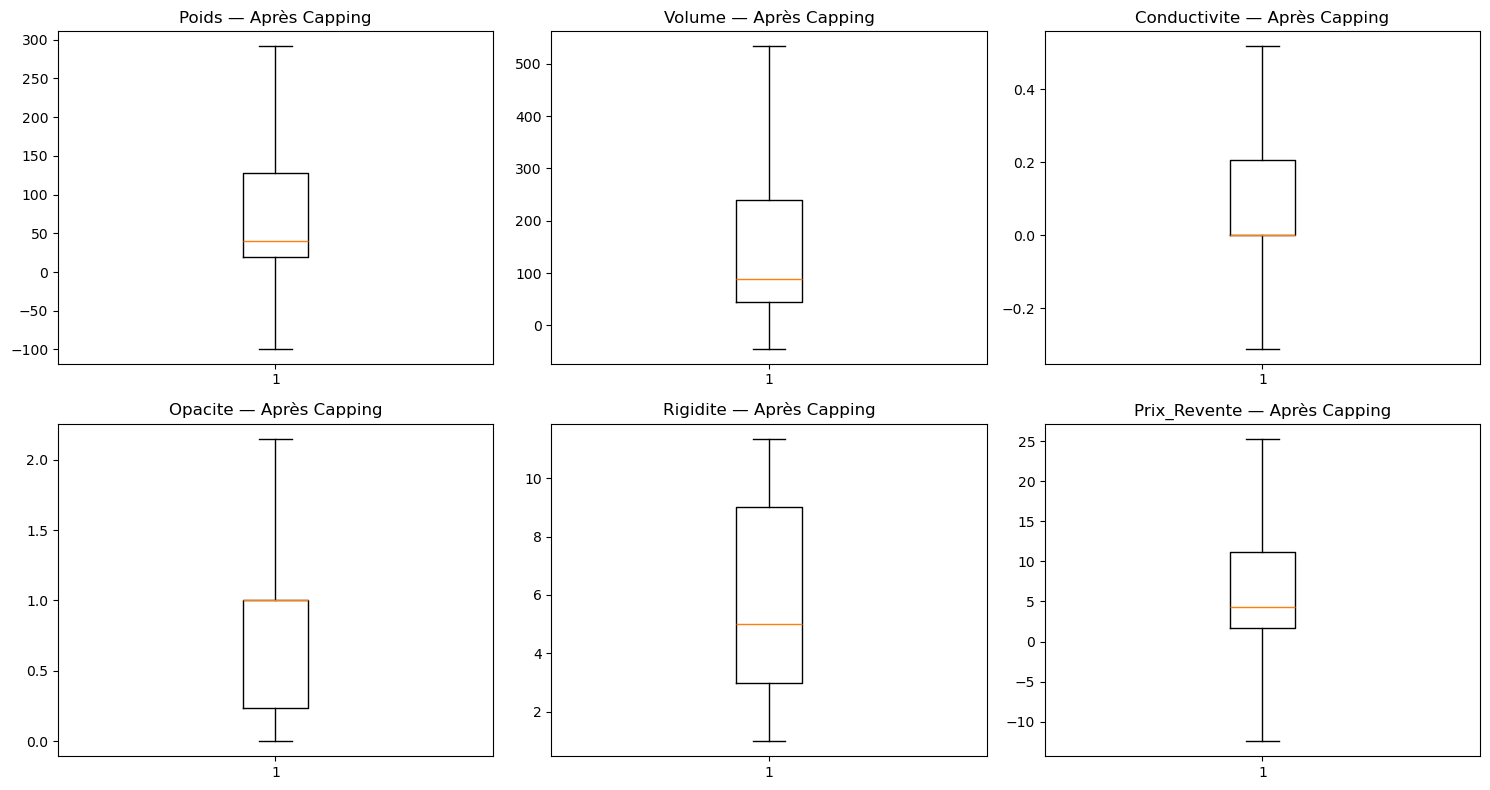

In [26]:
# ── Traitement des outliers par Capping (IQR) ──────────────
df_final = df_clean.copy()

for col in cols_numeriques:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    # Remplacer les valeurs hors bornes par les bornes
    df_final[col] = df_final[col].clip(lower=borne_inf, upper=borne_sup)

# ── Vérification ───────────────────────────────────────────
print("=== OUTLIERS APRÈS CAPPING ===")
for col in cols_numeriques:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    outliers = df_final[(df_final[col] < borne_inf) | (df_final[col] > borne_sup)]
    print(f"{col:<15} → {len(outliers)} outliers restants")

# ── Boxplots après capping ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numeriques):
    axes[i].boxplot(df_final[col])
    axes[i].set_title(f"{col} — Après Capping")

plt.tight_layout()
plt.savefig("boxplots_apres_capping.png")
plt.show()

=== APRÈS StandardScaler ===
           Poids     Volume  Conductivite    Opacite   Rigidite
count  10500.000  10500.000     10500.000  10500.000  10500.000
mean       0.000     -0.000        -0.000     -0.000     -0.000
std        1.000      1.000         1.000      1.000      1.000
min       -2.376     -1.395        -1.987     -1.550     -1.592
25%       -0.722     -0.735        -0.567     -1.009     -0.941
50%       -0.443     -0.406        -0.567      0.753     -0.290
75%        0.789      0.708         0.379      0.753      1.012
max        3.056      2.873         1.799      3.396      1.773

=== APRÈS MinMaxScaler ===
           Poids     Volume  Conductivite    Opacite   Rigidite
count  10500.000  10500.000     10500.000  10500.000  10500.000
mean       0.437      0.327         0.525      0.313      0.473
std        0.184      0.234         0.264      0.202      0.297
min        0.000      0.000         0.000      0.000      0.000
25%        0.304      0.155         0.375      

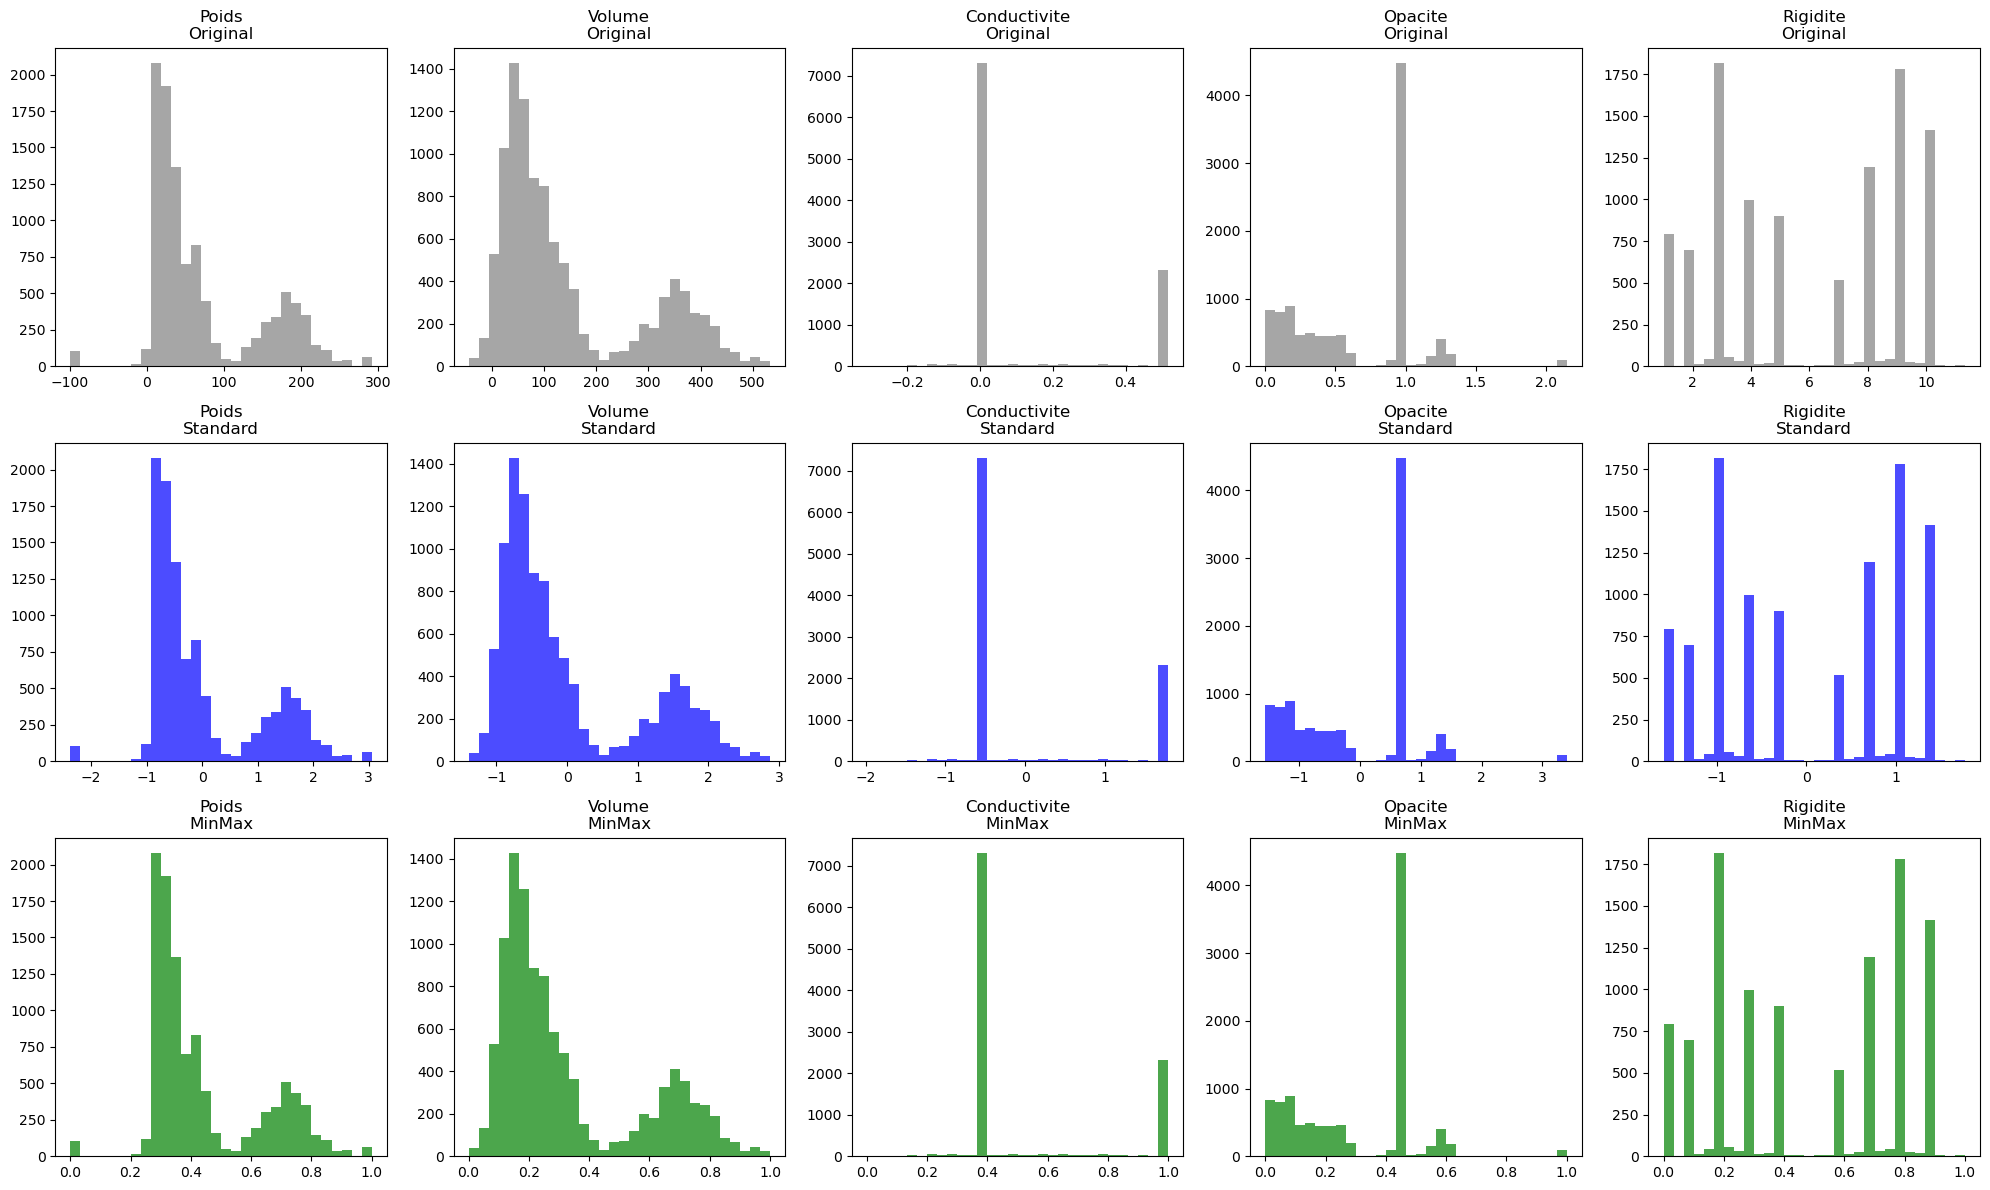

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── On ne normalise PAS Prix_Revente (c'est notre cible régression)
cols_a_normaliser = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

# ── Méthode 1 : StandardScaler ─────────────────────────────
df_standard = df_final.copy()
scaler_std = StandardScaler()
df_standard[cols_a_normaliser] = scaler_std.fit_transform(df_final[cols_a_normaliser])

# ── Méthode 2 : MinMaxScaler ───────────────────────────────
df_minmax = df_final.copy()
scaler_mm = MinMaxScaler()
df_minmax[cols_a_normaliser] = scaler_mm.fit_transform(df_final[cols_a_normaliser])

# ── Vérification ───────────────────────────────────────────
print("=== APRÈS StandardScaler ===")
print(df_standard[cols_a_normaliser].describe().round(3))

print("\n=== APRÈS MinMaxScaler ===")
print(df_minmax[cols_a_normaliser].describe().round(3))

# ── Visualisation ──────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for i, col in enumerate(cols_a_normaliser):
    # Original
    axes[0, i].hist(df_final[col], bins=30, color="gray", alpha=0.7)
    axes[0, i].set_title(f"{col}\nOriginal")
    
    # Standard
    axes[1, i].hist(df_standard[col], bins=30, color="blue", alpha=0.7)
    axes[1, i].set_title(f"{col}\nStandard")
    
    # MinMax
    axes[2, i].hist(df_minmax[col], bins=30, color="green", alpha=0.7)
    axes[2, i].set_title(f"{col}\nMinMax")

plt.tight_layout()
plt.savefig("normalisation.png")
plt.show()

In [28]:
# ── Vérifier les valeurs uniques ───────────────────────────
print("=== Valeurs uniques Source ===")
print(df_standard["Source"].unique())

print("\n=== Valeurs uniques Categorie ===")
print(df_standard["Categorie"].unique())
print(f"NaN dans Categorie : {df_standard['Categorie'].isnull().sum()}")

# ── Encodage Source → One-Hot Encoding ────────────────────
# Source n'a pas d'ordre → One-Hot
df_encoded = pd.get_dummies(df_standard, columns=["Source"], prefix="Source")

# ── Encodage Categorie → Label Encoding ───────────────────
# Categorie est notre cible → Label Encoding (0,1,2,3...)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# On encode seulement les lignes qui ont une valeur (pas les NaN)
mask = df_encoded["Categorie"].notna()
df_encoded.loc[mask, "Categorie_encoded"] = le.fit_transform(
    df_encoded.loc[mask, "Categorie"]
)

print("\n=== Mapping Categorie ===")
for i, cat in enumerate(le.classes_):
    print(f"  {cat} → {i}")

print("\n=== Aperçu final du dataset ===")
print(df_encoded.head())
print(f"\nShape final : {df_encoded.shape}")
print(f"\nColonnes : {list(df_encoded.columns)}")

=== Valeurs uniques Source ===
<StringArray>
[nan, 'Usine_A', 'Usine_B', 'Centre_Tri', 'Collecte_Citoyenne']
Length: 5, dtype: str

=== Valeurs uniques Categorie ===
<StringArray>
['Papier', 'Plastique', 'Verre', 'Métal', nan]
Length: 5, dtype: str
NaN dans Categorie : 514

=== Mapping Categorie ===
  Métal → 0
  Papier → 1
  Plastique → 2
  Verre → 3

=== Aperçu final du dataset ===
      Poids    Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0 -0.765850 -0.542351     -0.567329  0.753139 -1.591732      0.835439   
1 -0.340432 -0.588434     -0.567329  1.335981 -0.940721      4.727748   
2  1.390689  1.278456     -0.567329  0.708176  1.012313      4.211790   
3 -0.876987 -0.907781     -0.567329  1.433014 -1.591732      0.442067   
4 -0.579060 -0.627149     -0.567329  0.753139 -0.806789      0.723004   

   Categorie                                   Rapport_Collecte  \
0     Papier  Lot de papier récupéré dans un site non rensei...   
1  Plastique  Lot plastique à l'Usine A.

In [29]:
X = df_encoded.drop(columns=["Categorie", "Categorie_encoded", "Rapport_Collecte"])
y = df_encoded["Categorie_encoded"]

In [30]:
mask = y.notna()
X = X[mask]
y = y[mask]

In [31]:
print(f"Taille de X : {X.shape}")
print(f"Taille de y : {y.shape}")
print(f"\nDistribution des classes :")
print(y.value_counts())

Taille de X : (9986, 10)
Taille de y : (9986,)

Distribution des classes :
Categorie_encoded
2.0    2795
3.0    2586
1.0    2318
0.0    2287
Name: count, dtype: int64


In [32]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30,      # 30% pour val+test
    random_state=42, 
    stratify=y           # garder les mêmes proportions de classes
)

In [33]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [34]:
print(f"\n✅ Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"✅ Val   : {X_val.shape[0]} lignes ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"✅ Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)")


✅ Train : 6990 lignes (70.0%)
✅ Val   : 1498 lignes (15.0%)
✅ Test  : 1498 lignes (15.0%)


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ── Définir les modèles à tester ───────────────────────────
modeles = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM":                 SVC(random_state=42)
}

# ── Entraîner et évaluer chaque modèle ────────────────────
resultats = {}

for nom, modele in modeles.items():
    print(f"⏳ Entraînement : {nom}...")
    
    # Entraîner sur Train
    modele.fit(X_train, y_train)
    
    # Évaluer sur Validation
    y_pred = modele.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    resultats[nom] = acc
    
    print(f"✅ {nom} → Accuracy : {acc:.4f} ({acc*100:.2f}%)\n")

# ── Tableau comparatif ─────────────────────────────────────
print("\n=== COMPARAISON DES MODÈLES ===")
print(f"{'Modèle':<25} {'Accuracy':>10}")
print("-" * 37)
for nom, acc in sorted(resultats.items(), key=lambda x: x[1], reverse=True):
    print(f"{nom:<25} {acc*100:>9.2f}%")

⏳ Entraînement : Logistic Regression...
✅ Logistic Regression → Accuracy : 0.9806 (98.06%)

⏳ Entraînement : Random Forest...
✅ Random Forest → Accuracy : 0.9987 (99.87%)

⏳ Entraînement : Gradient Boosting...
✅ Gradient Boosting → Accuracy : 0.9987 (99.87%)

⏳ Entraînement : SVM...
✅ SVM → Accuracy : 0.9846 (98.46%)


=== COMPARAISON DES MODÈLES ===
Modèle                      Accuracy
-------------------------------------
Random Forest                 99.87%
Gradient Boosting             99.87%
SVM                           98.46%
Logistic Regression           98.06%


=== RAPPORT DÉTAILLÉ — Random Forest ===
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       347
   Plastique       1.00      1.00      1.00       420
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



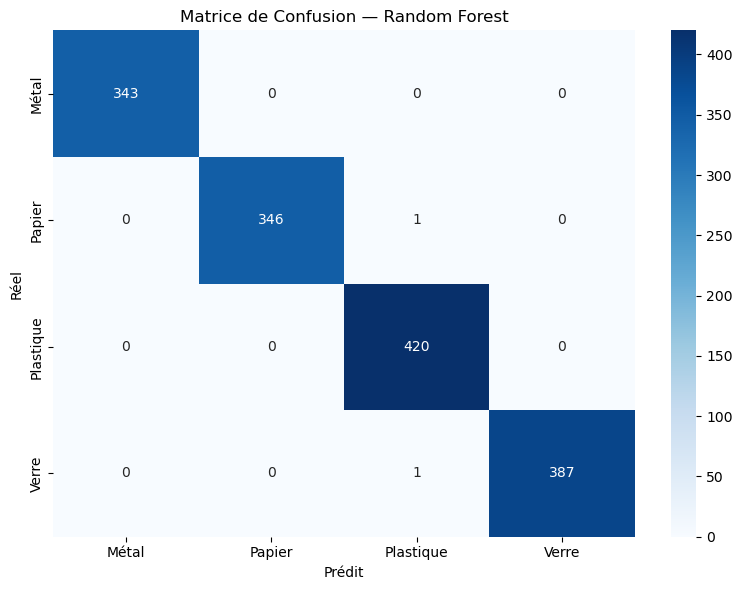

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

# Mapping pour afficher les vrais noms
noms_classes = {0.0: "Métal", 1.0: "Papier", 2.0: "Plastique", 3.0: "Verre"}

# ── Meilleur modèle → Random Forest ───────────────────────
meilleur_modele = modeles["Random Forest"]
y_pred_rf = meilleur_modele.predict(X_val)

# ── Rapport détaillé ───────────────────────────────────────
print("=== RAPPORT DÉTAILLÉ — Random Forest ===")
print(classification_report(
    y_val, y_pred_rf,
    target_names=["Métal", "Papier", "Plastique", "Verre"]
))

# ── Matrice de confusion ───────────────────────────────────
cm = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # afficher les chiffres
    fmt="d",             # format entier
    cmap="Blues",
    xticklabels=["Métal", "Papier", "Plastique", "Verre"],
    yticklabels=["Métal", "Papier", "Plastique", "Verre"]
)
plt.title("Matrice de Confusion — Random Forest")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

=== TOP FEATURES ===
                  Feature  Importance
                 Rigidite    0.226061
             Prix_Revente    0.170694
                   Volume    0.169288
                    Poids    0.158112
                  Opacite    0.137778
             Conductivite    0.136795
Source_Collecte_Citoyenne    0.000472
        Source_Centre_Tri    0.000304
           Source_Usine_A    0.000255
           Source_Usine_B    0.000241


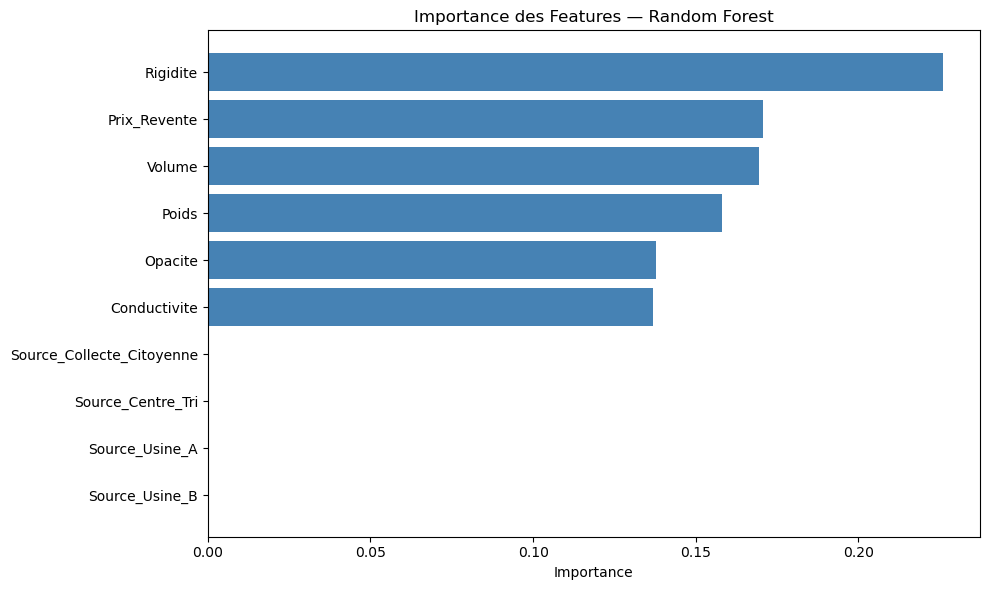

In [38]:
# ALTERNATIVE à SHAP — pas besoin d'installation
import matplotlib.pyplot as plt
import pandas as pd

# Importance des features directement depuis Random Forest
importances = meilleur_modele.feature_importances_
feature_names = X_val.columns

# Créer un dataframe trié
df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("=== TOP FEATURES ===")
print(df_importance.to_string(index=False))

# Graphique
plt.figure(figsize=(10, 6))
plt.barh(
    df_importance["Feature"][::-1],
    df_importance["Importance"][::-1],
    color="steelblue"
)
plt.title("Importance des Features — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV

# ── Paramètres à tester ────────────────────────────────────
param_grid = {
    "n_estimators": [100, 200],        # nombre d'arbres
    "max_depth": [None, 10, 20],       # profondeur max
    "min_samples_split": [2, 5],       # min échantillons pour diviser
}

print("⏳ GridSearchCV en cours... (peut prendre 2-3 minutes)")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,              # 5-fold cross validation
    scoring="accuracy",
    n_jobs=-1,         # utiliser tous les CPU
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres : {grid_search.best_params_}")
print(f"✅ Meilleure accuracy (CV) : {grid_search.best_score_*100:.2f}%")

# ── Évaluer sur le test final ──────────────────────────────
meilleur_rf = grid_search.best_estimator_
y_pred_test = meilleur_rf.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
print(f"✅ Accuracy sur Test : {acc_test*100:.2f}%")

⏳ GridSearchCV en cours... (peut prendre 2-3 minutes)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
✅ Meilleure accuracy (CV) : 99.91%
✅ Accuracy sur Test : 99.93%


In [40]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ── Préparer X et y pour la régression ────────────────────
# y = Prix_Revente (valeur numérique)
# Attention : Prix_Revente ne doit PAS être dans X !

X_reg = df_encoded.drop(columns=[
    "Categorie", "Categorie_encoded", 
    "Rapport_Collecte", "Prix_Revente"
])
y_reg = df_final["Prix_Revente"]  # valeurs originales avant normalisation

# Aligner les index
X_reg = X_reg.loc[y_reg.index]

# ── Split 70/15/15 ─────────────────────────────────────────
X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.50, random_state=42
)

print(f"✅ Train : {X_train_r.shape[0]} lignes")
print(f"✅ Val   : {X_val_r.shape[0]} lignes")
print(f"✅ Test  : {X_test_r.shape[0]} lignes")

✅ Train : 7350 lignes
✅ Val   : 1575 lignes
✅ Test  : 1575 lignes


In [41]:
modeles_reg = {
    "Linear Regression":    LinearRegression(),
    "Random Forest":        RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print("\n=== COMPARAISON MODÈLES RÉGRESSION ===")
print(f"{'Modèle':<25} {'R² Score':>10} {'RMSE':>10}")
print("-" * 47)

for nom, modele in modeles_reg.items():
    modele.fit(X_train_r, y_train_r)
    y_pred = modele.predict(X_val_r)
    
    r2   = r2_score(y_val_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_r, y_pred))
    
    print(f"{nom:<25} {r2:>10.4f} {rmse:>10.4f}")


=== COMPARAISON MODÈLES RÉGRESSION ===
Modèle                      R² Score       RMSE
-----------------------------------------------
Linear Regression             0.5538     5.0497
Random Forest                 0.6517     4.4620
Gradient Boosting             0.6699     4.3435


In [42]:
from sklearn.model_selection import GridSearchCV

param_grid_reg = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

print("⏳ GridSearchCV Régression en cours...")

grid_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train_r, y_train_r)

print(f"\n✅ Meilleurs paramètres : {grid_reg.best_params_}")
print(f"✅ Meilleur R² (CV)     : {grid_reg.best_score_:.4f}")

# ── Évaluer sur Test ───────────────────────────────────────
meilleur_reg = grid_reg.best_estimator_
y_pred_test_r = meilleur_reg.predict(X_test_r)

r2_test   = r2_score(y_test_r, y_pred_test_r)
rmse_test = np.sqrt(mean_squared_error(y_test_r, y_pred_test_r))

print(f"✅ R² sur Test  : {r2_test:.4f}")
print(f"✅ RMSE sur Test: {rmse_test:.4f}€")

⏳ GridSearchCV Régression en cours...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
✅ Meilleur R² (CV)     : 0.7055
✅ R² sur Test  : 0.7424
✅ RMSE sur Test: 3.9539€


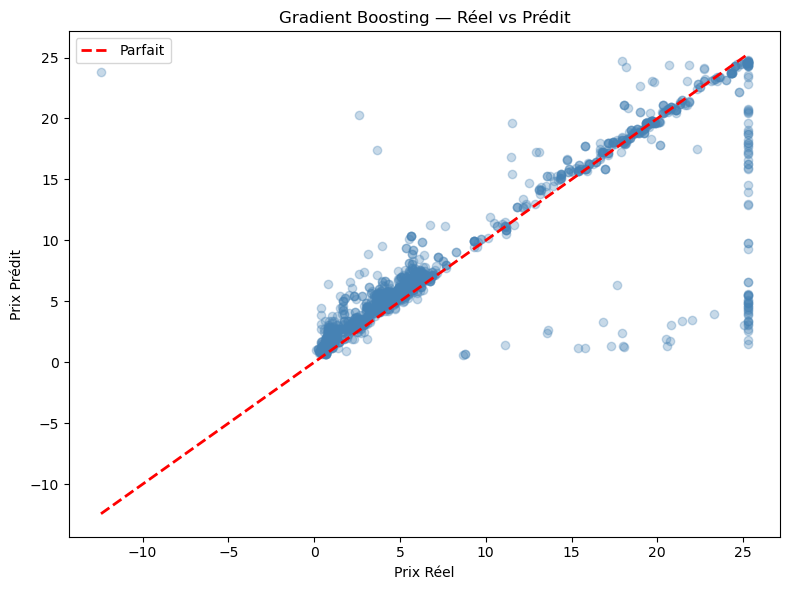

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_test_r, alpha=0.3, color="steelblue")
plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    "r--", linewidth=2, label="Parfait"
)
plt.xlabel("Prix Réel")
plt.ylabel("Prix Prédit")
plt.title("Gradient Boosting — Réel vs Prédit")
plt.legend()
plt.tight_layout()
plt.savefig("regression_predictions.png")
plt.show()

In [44]:
cols_clustering = ["Poids", "Volume", "Conductivite", 
                   "Opacite", "Rigidite"]

X_clust = df_final[cols_clustering].copy()

In [45]:
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

print(f"✅ Shape des données : {X_clust_scaled.shape}")
print(f"✅ Données normalisées — moyenne ≈ 0, std ≈ 1")

✅ Shape des données : (10500, 5)
✅ Données normalisées — moyenne ≈ 0, std ≈ 1


⏳ Test de k=1 à k=10...
  k=1 → inertie=52500.00
  k=2 → inertie=26190.14
  k=3 → inertie=10429.78
  k=4 → inertie=6677.18
  k=5 → inertie=5547.86
  k=6 → inertie=4946.56
  k=7 → inertie=4554.17
  k=8 → inertie=4272.64
  k=9 → inertie=3921.95
  k=10 → inertie=3741.83


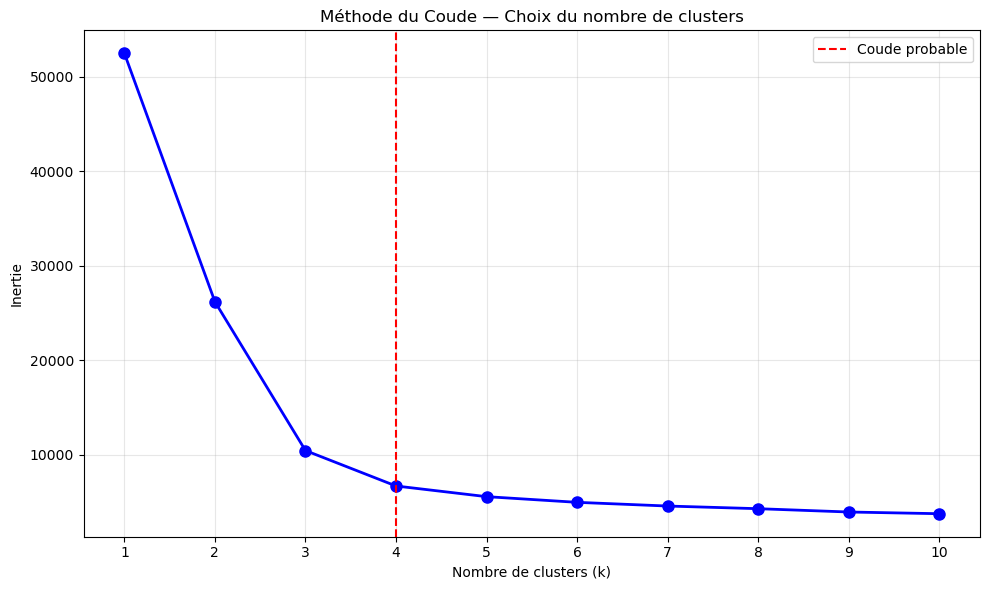

In [47]:
from sklearn.cluster import KMeans

# ── Méthode du Coude ───────────────────────────────────────
inerties = []
K_range = range(1, 11)

print("⏳ Test de k=1 à k=10...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    inerties.append(kmeans.inertia_)
    print(f"  k={k} → inertie={kmeans.inertia_:.2f}")

# ── Graphique du coude ─────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(K_range, inerties, "bo-", linewidth=2, markersize=8)
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du Coude — Choix du nombre de clusters")
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color="red", linestyle="--", label="Coude probable")
plt.legend()
plt.tight_layout()
plt.savefig("elbow_method.png")
plt.show()

In [48]:
# ── Appliquer K-Means avec k=4 ────────────────────────────
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_clust_scaled)

# ── Ajouter les clusters au dataframe ─────────────────────
df_final["Cluster"] = clusters

print("=== DISTRIBUTION DES CLUSTERS ===")
print(df_final["Cluster"].value_counts().sort_index())

# ── Caractéristiques de chaque cluster ────────────────────
print("\n=== MOYENNE PAR CLUSTER ===")
print(df_final.groupby("Cluster")[cols_clustering].mean().round(2))

=== DISTRIBUTION DES CLUSTERS ===
Cluster
0    2798
1    2634
2    2613
3    2455
Name: count, dtype: int64

=== MOYENNE PAR CLUSTER ===
          Poids  Volume  Conductivite  Opacite  Rigidite
Cluster                                                 
0         16.36   35.67         -0.00     1.07      2.32
1        182.91  356.70          0.01     0.18      9.05
2         27.17   66.04          0.01     0.40      4.03
3         63.02  123.76          0.50     1.04      8.55


Variance expliquée par PC1 : 58.6%
Variance expliquée par PC2 : 30.0%
Total expliqué             : 88.6%


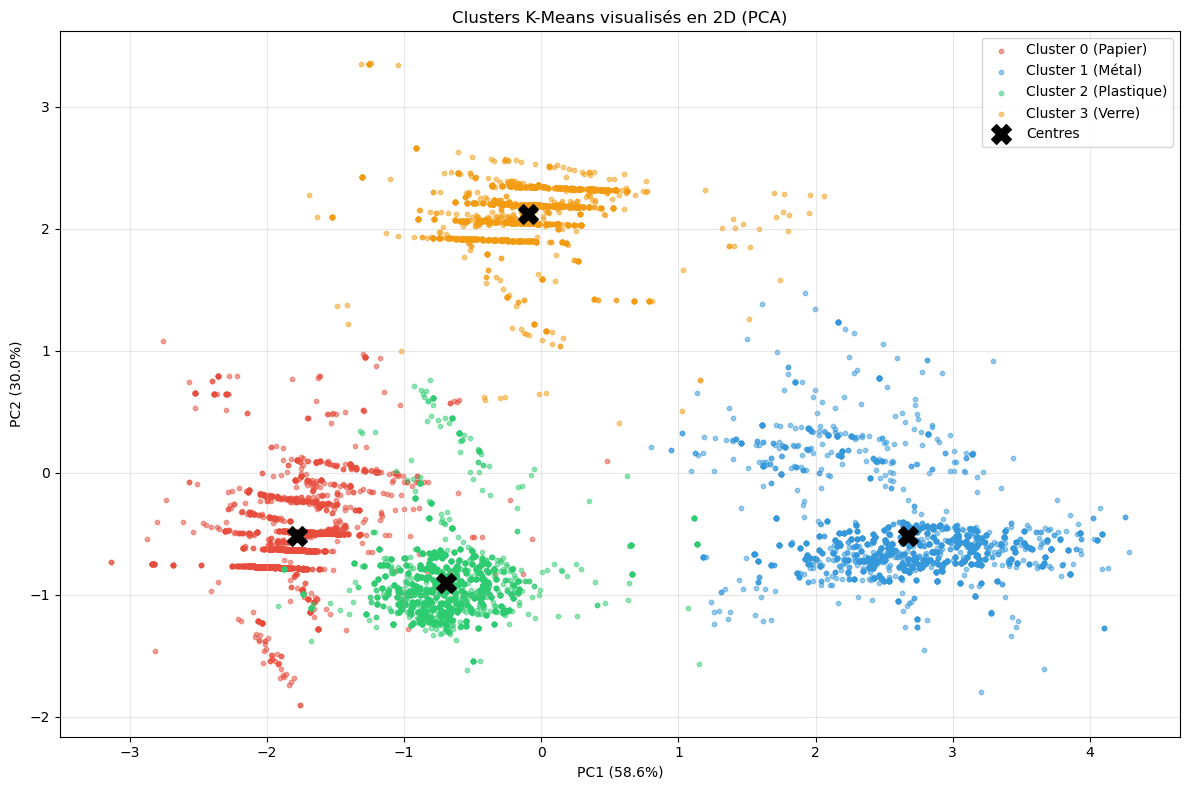

In [49]:
from sklearn.decomposition import PCA

# ── Réduire à 2 dimensions ─────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

print(f"Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total expliqué             : {sum(pca.explained_variance_ratio_)*100:.1f}%")

# ── Visualisation des clusters ─────────────────────────────
couleurs = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
noms_clusters = ["Cluster 0 (Papier)", "Cluster 1 (Métal)", 
                 "Cluster 2 (Plastique)", "Cluster 3 (Verre)"]

plt.figure(figsize=(12, 8))

for i in range(4):
    mask = clusters == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=couleurs[i],
        label=noms_clusters[i],
        alpha=0.5,
        s=10
    )

# Centres des clusters
centres_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(
    centres_pca[:, 0],
    centres_pca[:, 1],
    c="black",
    marker="X",
    s=200,
    zorder=5,
    label="Centres"
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Clusters K-Means visualisés en 2D (PCA)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("clusters_pca.png")
plt.show()